# Vol.02: リターン分布と出来高分布
**暗号資産データ分析入門シリーズ**

---

**テーマ**: 価格変動と出来高の統計的な性質を理解する

### なぜ「分布を知る」ことが決定的に重要なのか

多くの初心者がやりがちな失敗があります。リターンの平均と標準偏差だけを見て、「BTCは年率○%で、リスクは○%」と要約してしまうことです。これは **正規分布を暗黙に仮定している** のと同じです。

しかし現実の金融市場、とりわけ暗号資産市場のリターン分布は、正規分布とはまったく異なる形をしています。

- **ファットテール**: 「ありえないはず」の急変動が、正規分布の予測の何十倍もの頻度で起きる
- **歪み（スキュー）**: 上昇と下落が対称ではない
- **尖度（クルトシス）**: 中心付近にデータが集中し、裾が厚い

これらの性質を無視すると何が起きるか？

**リスクを致命的に過小評価します。** 正規分布では「±3σを超える変動は0.3%の確率」ですが、暗号資産では数%の頻度で発生します。正規分布を前提にポジションサイズを決めたトレーダーは、「1000年に1度」のはずの暴落で口座を吹き飛ばします。これは2008年の金融危機でウォール街のクオンツが犯したのと同じ過ちです。

### 分布を知ることで何が変わるか

分布の形状を正しく把握していれば、後続の全ての分析の質が変わります。

- **Vol.05（テクニカル指標）**: 指標の有効性を評価するとき、正規分布前提のt検定がそのまま使えるか判断できる
- **Vol.07（シグナルから損益曲線へ）**: シャープレシオの信頼性を適切に評価できる
- **Vol.08（頑健性検証）**: ドローダウンの深さが「想定内」かどうかの基準を持てる
- **Vol.10（ブートストラップ）**: なぜパラメトリック検定ではなくブートストラップが必要なのかが腑に落ちる

つまり、**このVol.02で分布の性質を体で理解しておくことが、残り8本のnotebookすべての土台になります**。

### 出来高の分布を知る意味

価格だけを見ていても市場の半分しか見えていません。出来高は「どれだけの参加者が、どれだけの資金を動かしたか」を直接示す指標です。

- 出来高を伴った上昇は「本物のトレンド」の可能性が高い
- 出来高が細った中での急変動は「流動性の低下によるノイズ」かもしれない
- 特定の時間帯に出来高が集中するパターンは、裁定機会やリスク管理に直結する

リターンの分布を知ることは「何が起きたか」を理解すること。出来高の分布を知ることは「なぜ起きたか」に迫る第一歩です。

### このnotebookで学ぶこと

1. **リターンのヒストグラム** — 価格変動の頻度分布を可視化する
2. **正規分布との比較** — 金融データが正規分布に従わないことを確認する
3. **基本統計量** — 歪度・尖度を使って分布の「形」を定量化する
4. **Q-Qプロット** — 正規分布からの乖離を視覚的に確認する
5. **出来高の分布特性** — 出来高の時間帯別パターンを把握する
6. **価格変動と出来高の関係** — 同時点での散布図で関連を探る
7. **銘柄間の比較** — BTC・ETH・SOLの分布特性を比較する

## 1. 環境準備

In [1]:
!pip install requests pandas numpy matplotlib japanize-matplotlib scipy -q

In [2]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
from scipy import stats
import time

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100
print("ライブラリの読み込み完了")

ライブラリの読み込み完了


## 2. データ取得

BTC・ETH・SOLの3銘柄について、1時間足と日足のデータを取得します。

In [3]:
BINANCE_API_URL = "https://api.binance.com/api/v3/klines"

def fetch_ohlcv(symbol, interval, start_date, end_date, limit=1000):
    """
    Binance REST API から OHLCV データを取得する。

    Parameters
    ----------
    symbol : str     — 銘柄（例: 'BTCUSDT'）
    interval : str   — 時間足（例: '1h', '5m', '1d'）
    start_date : str — 開始日（例: '2024-01-01'）
    end_date : str   — 終了日（例: '2025-01-01'）※この日は含まない
    limit : int      — 1回のリクエストあたりの取得本数（最大1000）

    Returns
    -------
    pd.DataFrame — columns: [open, high, low, close, volume], index: timestamp (UTC)
    """
    start_ts = int(pd.Timestamp(start_date, tz="UTC").timestamp() * 1000)
    end_ts = int(pd.Timestamp(end_date, tz="UTC").timestamp() * 1000)

    all_data = []
    current_ts = start_ts

    while current_ts < end_ts:
        params = {
            "symbol": symbol,
            "interval": interval,
            "startTime": current_ts,
            "endTime": end_ts - 1,  # endTime は inclusive なので -1
            "limit": limit,
        }
        resp = requests.get(BINANCE_API_URL, params=params, timeout=30)
        resp.raise_for_status()
        data = resp.json()

        if not data:
            break

        all_data.extend(data)
        current_ts = data[-1][0] + 1  # 最後のレコードの次から再開
        time.sleep(0.2)  # レートリミット遵守（200ms間隔）

    if not all_data:
        return pd.DataFrame(columns=["open", "high", "low", "close", "volume"])

    df = pd.DataFrame(all_data, columns=[
        "timestamp", "open", "high", "low", "close", "volume",
        "_close_time", "_quote_vol", "_trades", "_taker_buy_vol",
        "_taker_buy_quote", "_ignore",
    ])

    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms", utc=True)
    for col in ["open", "high", "low", "close", "volume"]:
        df[col] = df[col].astype(float)

    df = df[["timestamp", "open", "high", "low", "close", "volume"]]
    df = df.set_index("timestamp").sort_index()
    df = df[~df.index.duplicated(keep="first")]

    return df

# 取得設定
symbols = ['BTC/USDT', 'ETH/USDT', 'SOL/USDT']
since_date = '2024-01-01'
until_date = '2025-01-01'

# 1時間足データの取得
data_1h = {}
for sym in symbols:
    api_sym = sym.replace("/", "")  # BTC/USDT → BTCUSDT
    print(f"取得中: {sym} (1h)...", end=" ")
    data_1h[sym] = fetch_ohlcv(api_sym, '1h', since_date, until_date)
    print(f"{len(data_1h[sym]):,} 本")

# 日足データの取得
data_1d = {}
for sym in symbols:
    api_sym = sym.replace("/", "")
    print(f"取得中: {sym} (1d)...", end=" ")
    data_1d[sym] = fetch_ohlcv(api_sym, '1d', since_date, until_date)
    print(f"{len(data_1d[sym]):,} 本")

print("\n全データ取得完了")

取得中: BTC/USDT (1h)... 

8,784 本
取得中: ETH/USDT (1h)... 

8,784 本
取得中: SOL/USDT (1h)... 

8,784 本
取得中: BTC/USDT (1d)... 

366 本
取得中: ETH/USDT (1d)... 

366 本
取得中: SOL/USDT (1d)... 

366 本

全データ取得完了


In [4]:
# リターンの計算
for sym in symbols:
    data_1h[sym]['ret'] = data_1h[sym]['close'].pct_change()
    data_1d[sym]['ret'] = data_1d[sym]['close'].pct_change()

# 確認
print("--- 1時間足データの先頭 (BTC) ---")
print(data_1h['BTC/USDT'][['close', 'volume', 'ret']].head())
print(f"\n--- 日足データの先頭 (BTC) ---")
print(data_1d['BTC/USDT'][['close', 'volume', 'ret']].head())

--- 1時間足データの先頭 (BTC) ---
                              close      volume       ret
timestamp                                                
2024-01-01 00:00:00+00:00  42475.23  1271.68108       NaN
2024-01-01 01:00:00+00:00  42613.56  1196.37856  0.003257
2024-01-01 02:00:00+00:00  42581.10   685.21980 -0.000762
2024-01-01 03:00:00+00:00  42330.49   794.80391 -0.005885
2024-01-01 04:00:00+00:00  42399.99   715.41760  0.001642

--- 日足データの先頭 (BTC) ---
                              close       volume       ret
timestamp                                                 
2024-01-01 00:00:00+00:00  44179.55  27174.29903       NaN
2024-01-02 00:00:00+00:00  44946.91  65146.40661  0.017369
2024-01-03 00:00:00+00:00  42845.23  81194.55173 -0.046759
2024-01-04 00:00:00+00:00  44151.10  48038.06334  0.030479
2024-01-05 00:00:00+00:00  44145.11  48075.25327 -0.000136


## 3. リターンのヒストグラムと正規分布との比較

リターンがどのような分布をしているかを、ヒストグラムで確認します。
比較対象として、同じ平均・標準偏差の**正規分布**（ベルカーブ）を重ねてプロットします。

正規分布は統計学の最も基本的な分布で、多くの統計手法が正規分布を前提としています。
**金融データが正規分布にどの程度従うか（従わないか）を理解すること**は、分析の前提を正しく認識するために重要です。

> **リターンの種類について**: Vol.01 で説明したとおり、このシリーズでは**単純リターン**（`pct_change()`）を使用しています。対数リターンという選択肢もありますが、単純リターンは直感的に解釈しやすく（+0.01 = 1%上昇）、相関分析や5分位分析などの下流タスクにもそのまま使えるためです。

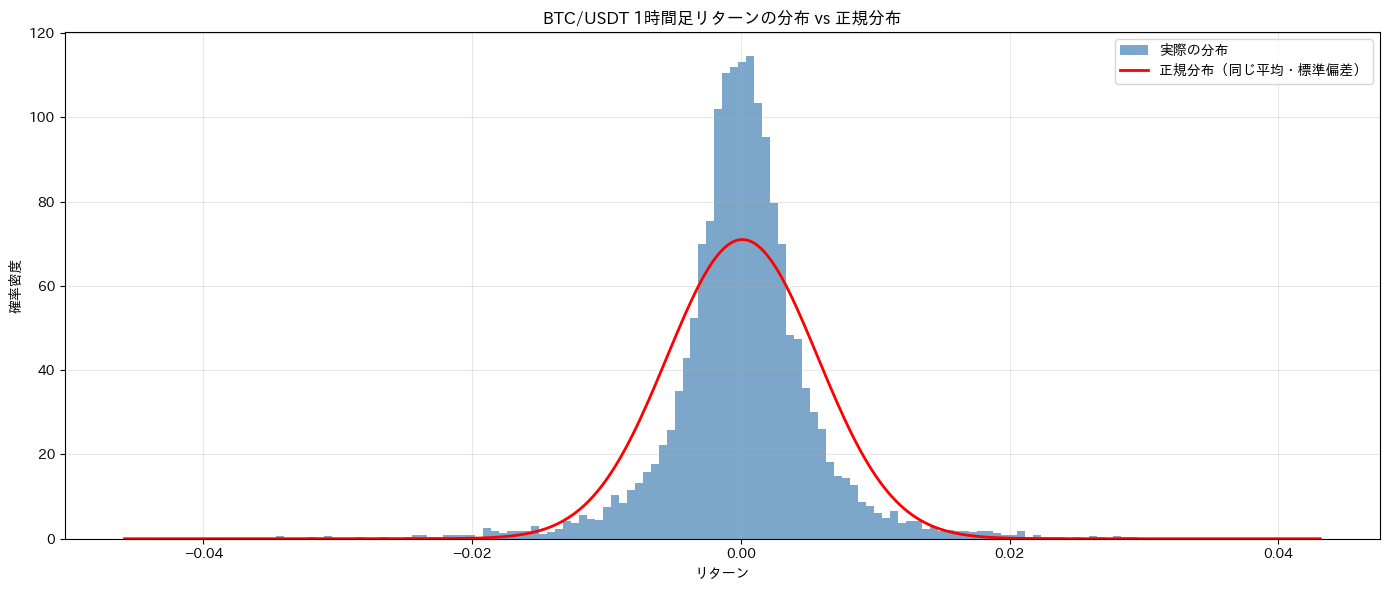

注目ポイント:
  - 中央部分: 実際の分布は正規分布よりも尖っている（中心に集中）
  - 裾の部分: 実際の分布は正規分布よりも裾が厚い（極端な値が多い）


In [5]:
# BTC/USDT 1時間足リターンのヒストグラム + 正規分布
returns = data_1h['BTC/USDT']['ret'].dropna()

fig, ax = plt.subplots(figsize=(14, 6))

# ヒストグラム（密度表示に正規化）
ax.hist(returns, bins=150, density=True, alpha=0.7, color='steelblue', edgecolor='none',
        label='実際の分布')

# 同じ平均・標準偏差の正規分布を重ねる
x = np.linspace(returns.min(), returns.max(), 300)
normal_pdf = stats.norm.pdf(x, loc=returns.mean(), scale=returns.std())
ax.plot(x, normal_pdf, color='red', linewidth=2, label='正規分布（同じ平均・標準偏差）')

ax.set_title('BTC/USDT 1時間足リターンの分布 vs 正規分布')
ax.set_xlabel('リターン')
ax.set_ylabel('確率密度')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("注目ポイント:")
print("  - 中央部分: 実際の分布は正規分布よりも尖っている（中心に集中）")
print("  - 裾の部分: 実際の分布は正規分布よりも裾が厚い（極端な値が多い）")

## 4. 基本統計量（歪度・尖度）

分布の「形」を数値で表す指標として、**歪度（Skewness）** と **尖度（Kurtosis）** があります。

| 指標 | 意味 | 正規分布の値 | 解釈 |
|------|------|-------------|------|
| **歪度** | 分布の左右対称性 | 0 | 正：右裾が長い（大きな上昇が多い）<br>負：左裾が長い（大きな下落が多い） |
| **尖度** | 分布の裾の厚さ | 3（超過尖度は0） | 3より大きい→裾が厚い（ファットテール）<br>3より小さい→裾が薄い |

> **超過尖度（Excess Kurtosis）** = 尖度 − 3 で計算します。0なら正規分布と同等です。

In [6]:
# 3銘柄の基本統計量を一覧表にする（1時間足・日足）
stats_list = []

for sym in symbols:
    for label, data in [('1時間足', data_1h), ('日足', data_1d)]:
        ret = data[sym]['ret'].dropna()
        stats_list.append({
            '銘柄': sym.replace('/USDT', ''),
            '時間足': label,
            '平均': ret.mean(),
            '標準偏差': ret.std(),
            '歪度': ret.skew(),
            '尖度（超過）': ret.kurtosis(),  # pandasのkurtosisは超過尖度（正規分布=0）
            '最小': ret.min(),
            '最大': ret.max(),
            'N': int(len(ret)),
        })

stats_df = pd.DataFrame(stats_list).set_index(['銘柄', '時間足'])
stats_df

平均      標準偏差        歪度     尖度（超過）        最小        最大     N
銘柄  時間足                                                                    
BTC 1時間足  0.000106  0.005617 -0.129445   7.603739 -0.045873  0.043109  8783
    日足    0.002438  0.027731  0.481105   2.018701 -0.083902  0.118834   365
ETH 1時間足  0.000066  0.006840 -0.133497  13.844268 -0.082143  0.092128  8783
    日足    0.001526  0.033954  0.755916   4.097126 -0.102776  0.192300   365
SOL 1時間足  0.000119  0.009840  0.134373   7.591205 -0.090465  0.096307  8783
    日足    0.002407  0.042981  0.187420   0.316740 -0.133218  0.129255   365

## 5. Q-Qプロット

**Q-Qプロット（Quantile-Quantile Plot）** は、データが特定の分布（ここでは正規分布）に
どの程度従っているかを視覚的に確認する方法です。

- データが正規分布に従っていれば、点は45度の直線上に並ぶ
- 直線から外れた部分は、正規分布からの乖離を示す
- 特に両端（裾）での乖離は「ファットテール」を意味する

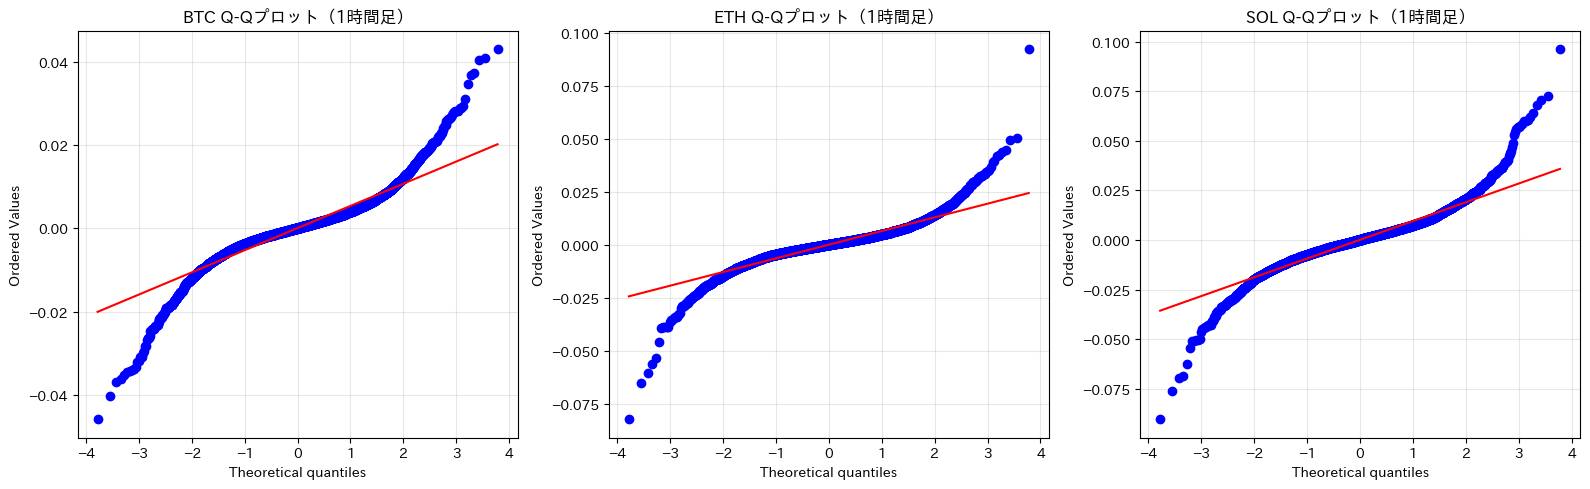

読み方:
  - 中央部: 直線に沿っている → 分布の中央部は正規分布に近い
  - 両端: 直線から上下に大きく外れる → ファットテール（極端な値が多い）


In [7]:
# 3銘柄のQ-Qプロット（1時間足）
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, sym in zip(axes, symbols):
    ret = data_1h[sym]['ret'].dropna()
    stats.probplot(ret, dist="norm", plot=ax)
    ax.set_title(f'{sym.replace("/USDT", "")} Q-Qプロット（1時間足）')
    ax.grid(True, alpha=0.3)
    # 45度線を強調
    ax.get_lines()[1].set_color('red')
    ax.get_lines()[1].set_linewidth(1.5)

plt.tight_layout()
plt.show()

print("読み方:")
print("  - 中央部: 直線に沿っている → 分布の中央部は正規分布に近い")
print("  - 両端: 直線から上下に大きく外れる → ファットテール（極端な値が多い）")

## 6. ファットテールの確認

「ファットテール」とは、正規分布と比べて極端な値（大きな上昇や下落）が多く発生する性質です。

これは金融データ分析において極めて重要な概念です。なぜなら：
- 正規分布を前提としたリスク管理は、実際のリスクを**過小評価**する
- 「100年に1度」の暴落が、実際には数年に1度起きる
- 暗号資産はとりわけファットテールが顕著

ここでは、正規分布で予測される極端な値の発生頻度と、実際の発生頻度を比較します。

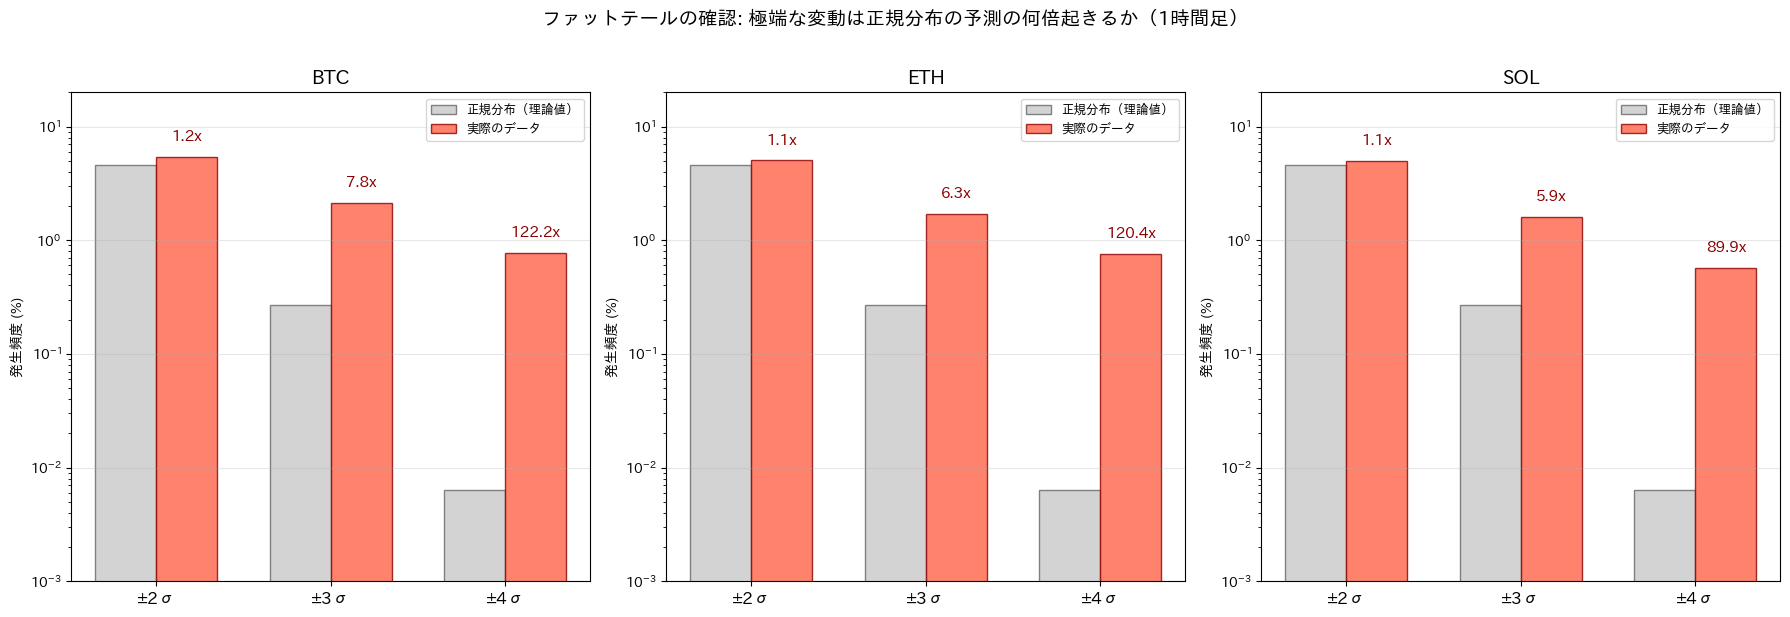


=== 発生頻度の比較（数値）===



正規分布（理論）    実際の頻度      倍率
銘柄  基準                           
BTC ±2σ  4.5500%  5.4196%    1.2x
    ±3σ  0.2700%  2.1177%    7.8x
    ±4σ  0.0063%  0.7742%  122.2x
ETH ±2σ  4.5500%  5.0324%    1.1x
    ±3σ  0.2700%  1.7078%    6.3x
    ±4σ  0.0063%  0.7628%  120.4x
SOL ±2σ  4.5500%  5.0097%    1.1x
    ±3σ  0.2700%  1.6054%    5.9x
    ±4σ  0.0063%  0.5693%   89.9x

In [8]:
# ファットテールの定量比較 + 可視化
# 正規分布で予測される頻度 vs 実際の頻度を、数値と棒グラフで比較する

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
thresholds = [2, 3, 4]

for ax, sym in zip(axes, symbols):
    ret = data_1h[sym]['ret'].dropna()
    mu, sigma = ret.mean(), ret.std()

    expected_pcts = []
    actual_pcts = []
    labels = []

    for n_sigma in thresholds:
        expected_pct = (1 - stats.norm.cdf(n_sigma) + stats.norm.cdf(-n_sigma)) * 100
        actual_pct = ((ret - mu).abs() > n_sigma * sigma).mean() * 100
        expected_pcts.append(expected_pct)
        actual_pcts.append(actual_pct)
        labels.append(f'±{n_sigma}σ')

    x = np.arange(len(thresholds))
    width = 0.35
    bars1 = ax.bar(x - width/2, expected_pcts, width, label='正規分布（理論値）',
                    color='lightgray', edgecolor='gray')
    bars2 = ax.bar(x + width/2, actual_pcts, width, label='実際のデータ',
                    color='tomato', edgecolor='darkred', alpha=0.8)

    # 倍率をバーの上に表示
    for j, (exp, act) in enumerate(zip(expected_pcts, actual_pcts)):
        ratio = act / exp if exp > 0 else float('inf')
        ax.text(x[j] + width/2, act * 1.3, f'{ratio:.1f}x',
                ha='center', va='bottom', fontsize=11, fontweight='bold', color='darkred')

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=12)
    ax.set_ylabel('発生頻度 (%)')
    ax.set_title(f'{sym.replace("/USDT", "")}', fontsize=14)
    ax.legend(fontsize=9)
    ax.set_yscale('log')  # 対数スケールで見やすく
    ax.set_ylim(0.001, 20)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('ファットテールの確認: 極端な変動は正規分布の予測の何倍起きるか（1時間足）',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 数値テーブルも表示
print("\n=== 発生頻度の比較（数値）===\n")
rows = []
for sym in symbols:
    ret = data_1h[sym]['ret'].dropna()
    mu, sigma = ret.mean(), ret.std()
    for n_sigma in thresholds:
        expected_pct = (1 - stats.norm.cdf(n_sigma) + stats.norm.cdf(-n_sigma)) * 100
        actual_pct = ((ret - mu).abs() > n_sigma * sigma).mean() * 100
        ratio = actual_pct / expected_pct if expected_pct > 0 else float('inf')
        rows.append({
            '銘柄': sym.replace('/USDT', ''),
            '基準': f'±{n_sigma}σ',
            '正規分布（理論）': f'{expected_pct:.4f}%',
            '実際の頻度': f'{actual_pct:.4f}%',
            '倍率': f'{ratio:.1f}x',
        })
pd.DataFrame(rows).set_index(['銘柄', '基準'])

## 7. 出来高の分布特性と時間帯別パターン

出来高（Volume）は「どれだけの取引が行われたか」を表す指標です。
価格と並んで市場の活発さを測る重要なデータです。

ここでは出来高の分布と、時間帯によるパターンを確認します。

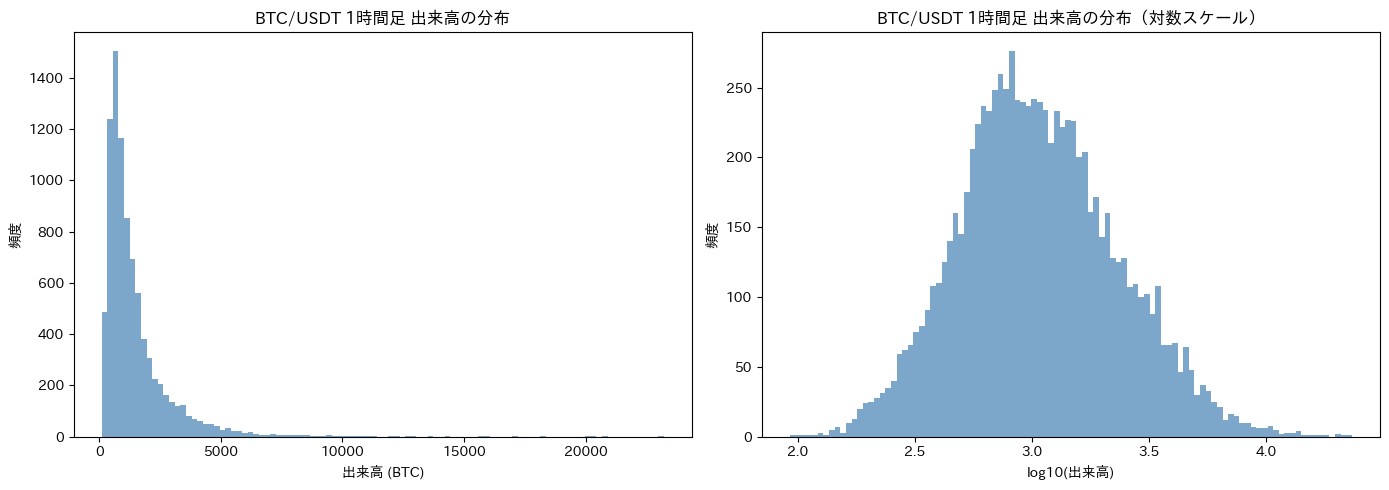

注目ポイント:
  - 出来高は正の値しかとらず、右に裾が長い分布（右歪み）
  - 対数変換すると、より対称的な分布に近づく


In [9]:
# BTC出来高のヒストグラム
btc_1h = data_1h['BTC/USDT']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左: 出来高の分布（元の値）
axes[0].hist(btc_1h['volume'], bins=100, alpha=0.7, color='steelblue', edgecolor='none')
axes[0].set_title('BTC/USDT 1時間足 出来高の分布')
axes[0].set_xlabel('出来高 (BTC)')
axes[0].set_ylabel('頻度')

# 右: 出来高の分布（対数スケール）
axes[1].hist(np.log10(btc_1h['volume'].replace(0, np.nan).dropna()),
             bins=100, alpha=0.7, color='steelblue', edgecolor='none')
axes[1].set_title('BTC/USDT 1時間足 出来高の分布（対数スケール）')
axes[1].set_xlabel('log10(出来高)')
axes[1].set_ylabel('頻度')

plt.tight_layout()
plt.show()

print("注目ポイント:")
print("  - 出来高は正の値しかとらず、右に裾が長い分布（右歪み）")
print("  - 対数変換すると、より対称的な分布に近づく")

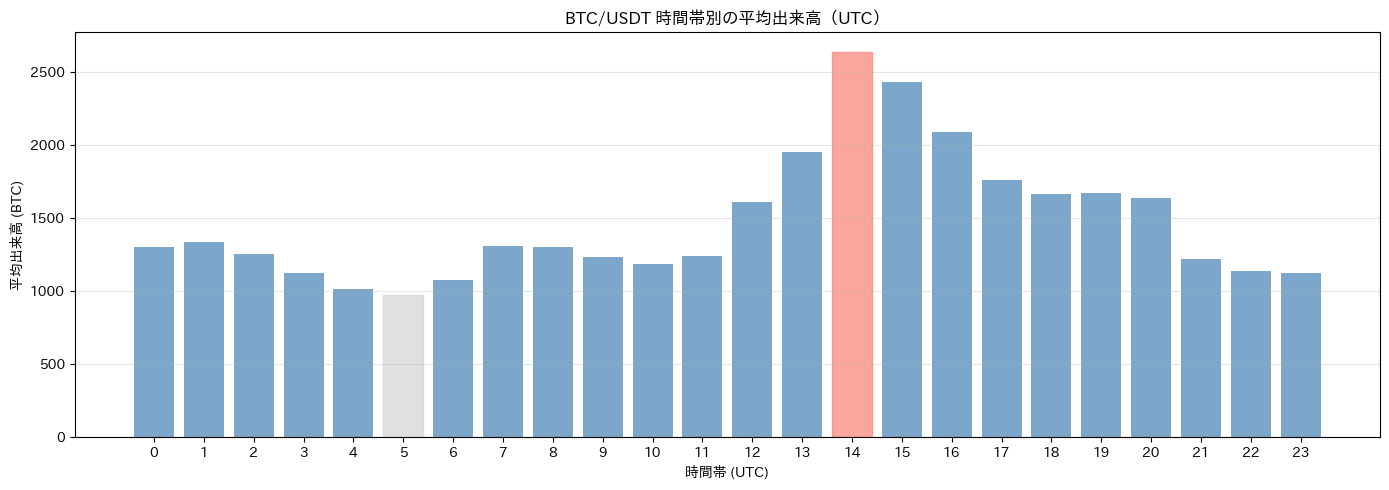

今回のサンプル（2024-01-01〜2025-01-01）での結果:
  出来高が最も多い時間帯: UTC 14時（赤）
  出来高が最も少ない時間帯: UTC 5時（灰）


In [10]:
# 時間帯別の平均出来高
btc_1h_copy = btc_1h.copy()
btc_1h_copy['hour'] = btc_1h_copy.index.hour

hourly_volume = btc_1h_copy.groupby('hour')['volume'].mean()

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(hourly_volume.index, hourly_volume.values, color='steelblue', alpha=0.7)

# 最大・最小の時間帯を強調
max_hour = hourly_volume.idxmax()
min_hour = hourly_volume.idxmin()
bars[max_hour].set_color('salmon')
bars[min_hour].set_color('lightgray')

ax.set_title('BTC/USDT 時間帯別の平均出来高（UTC）')
ax.set_xlabel('時間帯 (UTC)')
ax.set_ylabel('平均出来高 (BTC)')
ax.set_xticks(range(24))
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"今回のサンプル（{since_date}〜{until_date}）での結果:")
print(f"  出来高が最も多い時間帯: UTC {max_hour}時（赤）")
print(f"  出来高が最も少ない時間帯: UTC {min_hour}時（灰）")

## 8. 価格変動と出来高の関係

「出来高を伴った価格変動は信頼できる」という相場格言があります。
実際にデータで確認してみましょう。

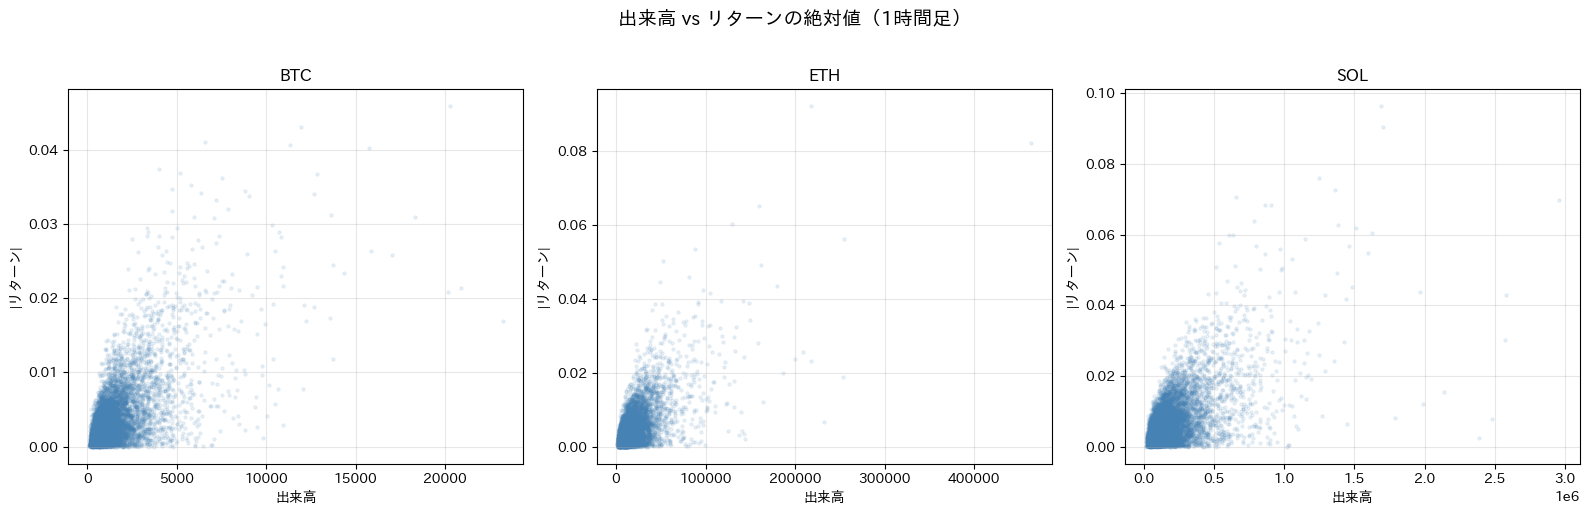

出来高と|リターン|の相関係数:
  銘柄       Pearson  Spearman
  ----------------------------
  BTC       0.6346    0.5289
  ETH       0.6478    0.5203
  SOL       0.5957    0.4818

※ Spearmanの方が大きい場合、出来高とリターン変動の関係は線形ではなく単調な関係


In [11]:
# 価格変動（リターンの絶対値）と出来高の散布図
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, sym in zip(axes, symbols):
    df = data_1h[sym].dropna(subset=['ret'])
    abs_return = df['ret'].abs()
    volume = df['volume']

    ax.scatter(volume, abs_return, alpha=0.1, s=5, color='steelblue')
    ax.set_title(f'{sym.replace("/USDT", "")}')
    ax.set_xlabel('出来高')
    ax.set_ylabel('|リターン|')
    ax.grid(True, alpha=0.3)

plt.suptitle('出来高 vs リターンの絶対値（1時間足）', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# 相関係数の計算（ピアソンとスピアマンの両方）
# ピアソン: 線形関係を測る。外れ値に影響されやすい
# スピアマン: 順位相関。外れ値に強く、単調な関係を捉える
print("出来高と|リターン|の相関係数:")
print(f"  {'銘柄':<6}  {'Pearson':>8}  {'Spearman':>8}")
print("  " + "-" * 28)
for sym in symbols:
    df = data_1h[sym].dropna(subset=['ret'])
    pearson = df['volume'].corr(df['ret'].abs())
    spearman = df['volume'].corr(df['ret'].abs(), method='spearman')
    name = sym.replace('/USDT', '')
    print(f"  {name:<6}  {pearson:>8.4f}  {spearman:>8.4f}")
print("\n※ Spearmanの方が大きい場合、出来高とリターン変動の関係は線形ではなく単調な関係")

## 9. BTC / ETH / SOL の分布比較

3銘柄のリターン分布を重ねて比較し、銘柄ごとの特性の違いを確認します。

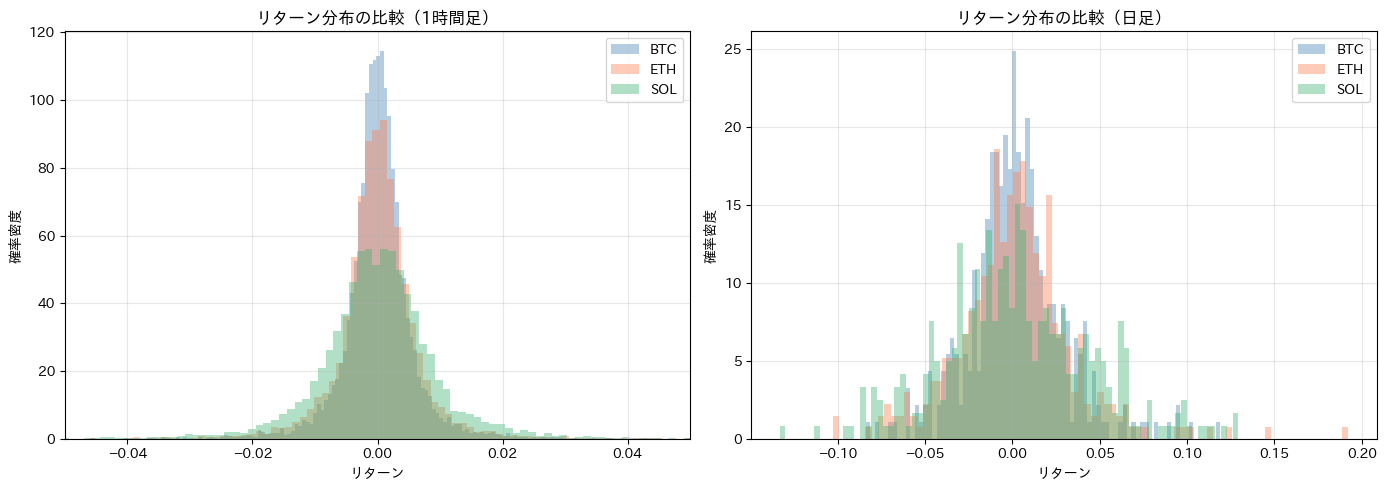

In [12]:
# 3銘柄のリターン分布を重ねてプロット
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {'BTC/USDT': 'steelblue', 'ETH/USDT': 'coral', 'SOL/USDT': 'mediumseagreen'}

# 左: 1時間足
for sym in symbols:
    ret = data_1h[sym]['ret'].dropna()
    axes[0].hist(ret, bins=150, density=True, alpha=0.4, color=colors[sym],
                 label=sym.replace('/USDT', ''), edgecolor='none')
axes[0].set_title('リターン分布の比較（1時間足）')
axes[0].set_xlabel('リターン')
axes[0].set_ylabel('確率密度')
axes[0].legend()
axes[0].set_xlim(-0.05, 0.05)  # 中央部分を拡大
axes[0].grid(True, alpha=0.3)

# 右: 日足
for sym in symbols:
    ret = data_1d[sym]['ret'].dropna()
    axes[1].hist(ret, bins=80, density=True, alpha=0.4, color=colors[sym],
                 label=sym.replace('/USDT', ''), edgecolor='none')
axes[1].set_title('リターン分布の比較（日足）')
axes[1].set_xlabel('リターン')
axes[1].set_ylabel('確率密度')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

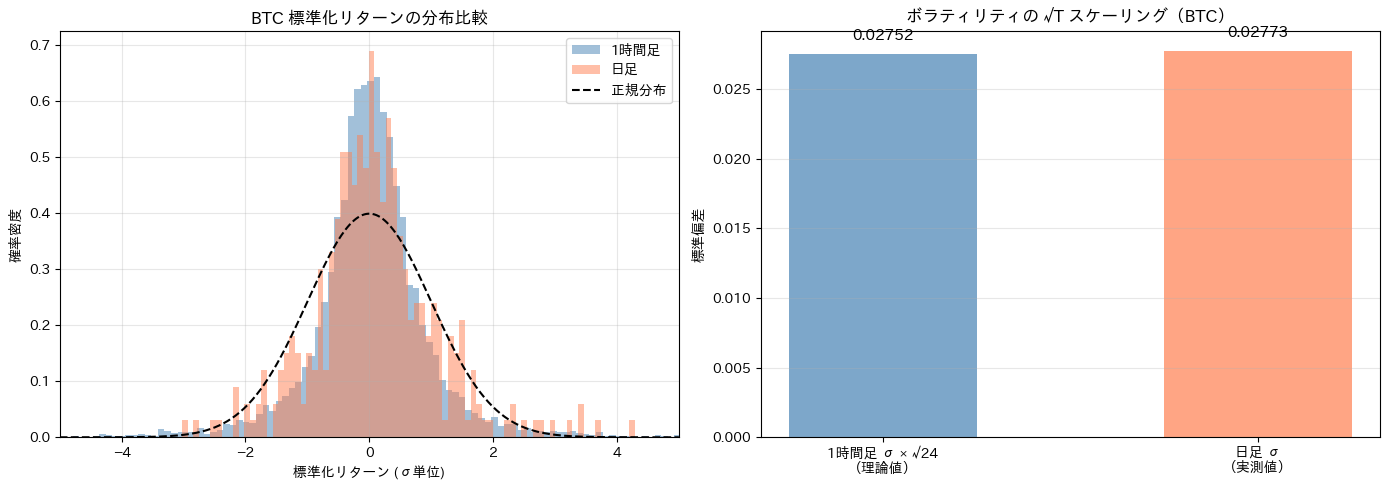

=== ボラティリティの √T スケーリング検証 ===

  1時間足の標準偏差 (σ_1h):      0.005617
  σ_1h × √24（理論値）:           0.027519
  日足の標準偏差（実測値）:        0.027731
  実測値 / 理論値 = 1.008

  → 比率が 1.008 で 1.0 に近く、√T スケーリングがよく成立しています。
    1時間足のリターンが概ね独立であることを示唆しています。

  【補足】√T スケーリングとは
  リターンが独立同分布なら、分散は時間に比例し、標準偏差は √時間 に比例します。
  これが成り立つかどうかは、リターンの自己相関構造を間接的に示す指標です。


In [13]:
# =============================================
# 時間足による分布の違い（BTCで比較）
# =============================================
#
# 目的:
#   1時間足と日足でリターン分布の「形」が変わるかを確認する。
#   具体的には以下の2つを検証する。
#
#   (1) 標準化（σ=1に揃える）した分布を重ねて、形状の違いを比較する
#   (2) ボラティリティが √時間 に比例するか（√Tスケーリング）を確認する

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ret_1h = data_1h['BTC/USDT']['ret'].dropna()
ret_1d = data_1d['BTC/USDT']['ret'].dropna()

# ──────────────────────────────────────────────
# 左: 標準化リターン分布の比較
# ──────────────────────────────────────────────
# リターンを各時間足の標準偏差で割ることで「σ=1」に正規化する。
# もし分布の形が時間足によらず同じなら、両者のヒストグラムは重なるはず。
axes[0].hist(ret_1h / ret_1h.std(), bins=150, density=True, alpha=0.5,
             color='steelblue', label='1時間足', edgecolor='none')
axes[0].hist(ret_1d / ret_1d.std(), bins=80, density=True, alpha=0.5,
             color='coral', label='日足', edgecolor='none')
x = np.linspace(-5, 5, 300)
axes[0].plot(x, stats.norm.pdf(x), 'k--', linewidth=1.5, label='正規分布')
axes[0].set_title('BTC 標準化リターンの分布比較')
axes[0].set_xlabel('標準化リターン (σ単位)')
axes[0].set_ylabel('確率密度')
axes[0].legend()
axes[0].set_xlim(-5, 5)
axes[0].grid(True, alpha=0.3)

# ──────────────────────────────────────────────
# 右: ボラティリティの √T スケーリング確認
# ──────────────────────────────────────────────
# リターンが各足で独立なら、日足のボラティリティは
#   σ(日足) ≈ σ(1時間足) × √24
# で近似できる（日足 = 1時間足 × 24本 のため）。
#
# この近似が成り立つかを検証する。
# 成り立つ場合: リターンの分散が時間に比例 → 各足のリターンがおおむね独立
# 成り立たない場合: ボラティリティ・クラスタリングや時間帯効果が強い

scaling_factor = np.sqrt(24)
approx_daily_vol = ret_1h.std() * scaling_factor
actual_daily_vol = ret_1d.std()
ratio = actual_daily_vol / approx_daily_vol

labels = ['1時間足 σ × √24\n（理論値）', '日足 σ\n（実測値）']
values = [approx_daily_vol, actual_daily_vol]
bar_colors = ['steelblue', 'coral']
bars = axes[1].bar(labels, values, color=bar_colors, alpha=0.7, width=0.5)
axes[1].set_title('ボラティリティの √T スケーリング（BTC）')
axes[1].set_ylabel('標準偏差')
for bar, v in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v + 0.001,
                 f'{v:.5f}', ha='center', fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# 結果の解説
print("=== ボラティリティの √T スケーリング検証 ===\n")
print(f"  1時間足の標準偏差 (σ_1h):      {ret_1h.std():.6f}")
print(f"  σ_1h × √24（理論値）:           {approx_daily_vol:.6f}")
print(f"  日足の標準偏差（実測値）:        {actual_daily_vol:.6f}")
print(f"  実測値 / 理論値 = {ratio:.3f}")
print()
if 0.9 <= ratio <= 1.1:
    print(f"  → 比率が {ratio:.3f} で 1.0 に近く、√T スケーリングがよく成立しています。")
    print("    1時間足のリターンが概ね独立であることを示唆しています。")
else:
    print(f"  → 比率が {ratio:.3f} で 1.0 からずれています。")
    if ratio > 1.1:
        print("    日足の実測ボラが大きい → ボラティリティ・クラスタリングの影響が考えられます。")
    else:
        print("    日足の実測ボラが小さい → 日中の平均回帰効果が考えられます。")
print()
print("  【補足】√T スケーリングとは")
print("  リターンが独立同分布なら、分散は時間に比例し、標準偏差は √時間 に比例します。")
print("  これが成り立つかどうかは、リターンの自己相関構造を間接的に示す指標です。")

## 10. まとめ

このnotebookでは、暗号資産の **リターン分布と出来高分布** の統計的な性質を学びました。

### 学んだこと

| テーマ | 内容 | ポイント |
|--------|------|---------|
| ヒストグラム | リターンの頻度分布を可視化 | 正規分布を重ねることで乖離が見える |
| 歪度・尖度 | 分布の「形」を数値化 | 超過尖度が大きい＝ファットテール |
| Q-Qプロット | 正規分布からの乖離を視覚確認 | 両端の乖離がファットテールを示す |
| ファットテール | 極端な値の出現頻度 | ±3σ超は正規分布の予測より数倍多い |
| 出来高分布 | 右歪みの分布、時間帯パターン | 欧米市場時間帯に出来高が集中 |
| 出来高とリターン | 散布図で正の相関を確認 | 大きな価格変動は出来高を伴う傾向 |
| 銘柄比較 | SOL > ETH > BTC の順にボラが高い | 時価総額が小さいほど変動が大きい |

### 次のステップ

**Vol.03: 相関分析** では、複数銘柄間の関係性を相関係数やローリング相関で定量的に分析します。

## 分析結果から分かったこと

### リターン分布の特性
- **全銘柄でファットテールが確認された**: 超過尖度はBTC 7.7, ETH 13.9, SOL 7.6（1時間足）で、いずれも正規分布（0）を大きく上回る
- **±4σの異常変動は正規分布の約120倍の頻度で発生**: 正規分布では0.006%（16,000本に1回）のはずが、実際には約0.76%（130本に1回）発生している
- ETHの超過尖度（13.9）がBTC・SOLの約2倍であり、稀に極めて大きな変動が起きやすいことを示している

### 出来高の特性
- 出来高はUTC 14時（米国東部午前10時、ニューヨーク市場の活発な時間帯）に最大、UTC 5時（アジア市場の端境期）に最小
- 出来高と|リターン|のPearson相関は0.60〜0.65、Spearman相関は0.48〜0.52で、いずれも中程度の正の相関。大きな価格変動時には出来高も増加する傾向が確認された
- Pearson > Spearmanとなっており、大きな出来高を伴う極端な変動が相関を押し上げている可能性がある

### ボラティリティのスケーリング
- BTCの√24スケーリングの実測比率は **1.000** で、近似が極めて良好だった
- これは2024年のBTCの1時間足リターンが比較的均一な分散を持っていたことを示唆している

### 銘柄間の違い
- ボラティリティ（1時間足σ）: SOL（0.98%）> ETH（0.68%）> BTC（0.56%）
- 一般に時価総額が小さい銘柄ほどボラティリティが高い傾向と一致している